# Sinh mô tả ảnh (Image Captioning) sử dụng Attention

## Mục tiêu

Mục tiêu của dự án là xây dựng mô hình học sâu có khả năng
tự động sinh mô tả (caption) cho hình ảnh.

Mô hình sử dụng kiến trúc:
- Encoder: CNN để trích xuất đặc trưng ảnh
- Decoder: LSTM để sinh câu
- Attention: Giúp mô hình tập trung vào vùng ảnh quan trọng

In [1]:
from collections import Counter
from PIL import Image
import numpy as np
import os
import tensorflow as tf
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from tqdm import tqdm

## Tiền xử lý văn bản (Caption Preprocessing)

Trong bước này, các câu mô tả được làm sạch và chuẩn hóa trước khi đưa vào huấn luyện.

Các bước thực hiện:
- Chuyển toàn bộ chữ về chữ thường
- Loại bỏ ký tự đặc biệt
- Tách từ (tokenization)
- Thêm token pad,unk,start,end
- Xây dựng từ điển ánh xạ word2idx và idx2word

Mục đích:
Chuyển dữ liệu văn bản thành dạng số để phù hợp với mô hình LSTM.

In [3]:
# Đường dẫn đến thư mục ảnh và file caption
img = "data/Images/"
data = "data/captions.txt"

In [4]:
#Hàm làm sạch caption
def clean_captions(data):
    data['caption'] = data['caption'].apply(lambda x: x.lower()) # Chuyển về chữ thường
    data['caption'] = data['caption'].apply(lambda x: re.sub(r'[^a-z]', ' ', x)) #Loại bỏ ký tự đặc biệt không phải chữ cái, chỉ giữ a-z
    data['caption'] = data['caption'].apply(lambda x: re.sub(r'\s+', ' ', x).strip()) # Xóa khoảng trắng thừa
    data['caption'] = data['caption'].apply(lambda x: " ".join([word for word in x.split() if len(word) > 1])) #Loại bỏ từ có độ dài <=1
    return data

In [5]:
#Kiểm tra lại bộ dữ liệu sau khi làm sạch
read_data = pd.read_csv(data)   
read_data = clean_captions(read_data)          
read_data.head(10)                             

,image,caption
0,1000268201_693b08cb0e.jpg,child in pink dress is climbing up set of stai...
1,1000268201_693b08cb0e.jpg,girl going into wooden building
2,1000268201_693b08cb0e.jpg,little girl climbing into wooden playhouse
3,1000268201_693b08cb0e.jpg,little girl climbing the stairs to her playhouse
4,1000268201_693b08cb0e.jpg,little girl in pink dress going into wooden cabin
5,1001773457_577c3a7d70.jpg,black dog and spotted dog are fighting
6,1001773457_577c3a7d70.jpg,black dog and tri colored dog playing with eac...
7,1001773457_577c3a7d70.jpg,black dog and white dog with brown spots are s...
8,1001773457_577c3a7d70.jpg,two dogs of different breeds looking at each o...
9,1001773457_577c3a7d70.jpg,two dogs on pavement moving toward each other


In [6]:
from collections import Counter

# Thêm token <start> và <end> trên caption đã clean
read_data["final_caption"] = read_data["caption"].apply(
    lambda x: "<start> " + x + " <end>"
)
# Tách từ
all_captions = []
for cap in read_data["final_caption"]:
    all_captions.extend(cap.split(" "))
# Đếm tần suất
word_freq = Counter(all_captions)
SPECIAL_TOKENS = ["<pad>", "<start>", "<end>", "<unk>"]

word2idx = {}
idx2word = {}
# Gán id cho token đặc biệt trước
for idx, tok in enumerate(SPECIAL_TOKENS):
    word2idx[tok] = idx
    idx2word[idx] = tok

# Giới hạn số lượng từ
threshold = 3  # giữ từ xuất hiện >= 3 lần

for word, count in word_freq.items():
    if count >= threshold:
        if word not in word2idx:   # tránh đè lên <start>, <end>
            new_id = len(word2idx)
            word2idx[word] = new_id
            idx2word[new_id] = word

print("Số lượng từ trong từ điển:", len(word2idx))
print("Ví dụ 15 từ đầu:", list(word2idx.items())[:15])
print("Id của <unk>:", word2idx["<unk>"])

Số lượng từ trong từ điển: 4059
Ví dụ 15 từ đầu: [('<pad>', 0), ('<start>', 1), ('<end>', 2), ('<unk>', 3), ('child', 4), ('in', 5), ('pink', 6), ('dress', 7), ('is', 8), ('climbing', 9), ('up', 10), ('set', 11), ('of', 12), ('stairs', 13), ('an', 14)]
Id của <unk>: 3


## Tiền xử lý ảnh

Trước khi đưa vào mô hình, ảnh được chuẩn hóa để đảm bảo kích thước
và định dạng đồng nhất.

Các bước bao gồm:
- Resize về kích thước cố định (299x299)
- Chuyển ảnh sang tensor
- Chuẩn hóa giá trị pixel
- Phân chia dữ liệu 

Việc này giúp mô hình CNN trích xuất đặc trưng hiệu quả hơn.

In [8]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.inception_v3 import preprocess_input

# Tạo hàm tiền xử lý ảnh
def prepare_image(image_path, target_size=(299, 299)):
 
    #  Tải ảnh và resize về (299, 299)
    img = load_img(image_path, target_size=target_size)
    #  Chuyển ảnh thành mảng NumPy (shape: (299, 299, 3))
    img = img_to_array(img)
    #  Tạo "mảng nhiều chiều" (thêm chiều batch) 
    # Shape đổi thành (1, 299, 299, 3)
    img = np.expand_dims(img, axis=0)
    # Chuẩn hóa ảnh theo đúng cách của InceptionV3 (về [-1, 1])
    img = preprocess_input(img)
    return img

In [9]:
#  Phân chia dữ liệu (Train, Validation, Test)
# Thêm đường dẫn đầy đủ vào DataFrame
img_dir = img # "data/Images/"
read_data['image_path'] = read_data['image'].apply(lambda x: os.path.join(img_dir, x))
# Lấy danh sách tất cả các ĐƯỜNG DẪN ẢNH DUY NHẤT
unique_image_paths = read_data['image_path'].unique()
print(f"Tổng số ảnh duy nhất: {len(unique_image_paths)}")
# Định nghĩa tỷ lệ và random_state
VAL_SIZE = 0.2  # 20% cho Validation
TEST_SIZE = 0.2 # 20% cho Test
RANDOM_SEED = 42 # Để đảm bảo kết quả chia luôn giống nhau
# Tách 20% làm TẬP TEST
# (80% còn lại là 'train_val')
train_val_paths, test_paths = train_test_split(
    unique_image_paths,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED
)
# Tách 80% còn lại thành TRAIN và VALIDATION
# (test_size ở đây được tính trên 80% còn lại, không phải tổng thể)
split_ratio = VAL_SIZE / (1.0 - TEST_SIZE) # 0.2 / (1.0 - 0.2) = 0.2 / 0.8 = 0.25

train_paths, val_paths = train_test_split(
    train_val_paths,
    test_size=split_ratio,
    random_state=RANDOM_SEED
)
# Tạo 3 DataFrame cuối cùng bằng cách lọc từ `read_data`
# Dùng .isin() để kiểm tra xem 'image_path' có nằm trong danh sách đã chia không
train_data = read_data[read_data['image_path'].isin(train_paths)]
val_data = read_data[read_data['image_path'].isin(val_paths)]
test_data = read_data[read_data['image_path'].isin(test_paths)]

# In kết quả để kiểm tra
print("---")
print(f"Tổng số dữ liệu: {len(read_data)} captions")
print(f"Tập Huấn luyện (Train): {len(train_data)} captions ({len(train_paths)} ảnh)")
print(f"Tập Xác thực (Validation): {len(val_data)} captions ({len(val_paths)} ảnh)")
print(f"Tập Kiểm tra (Test): {len(test_data)} captions ({len(test_paths)} ảnh)")

# Kiểm tra xem có bị rò rỉ không (kết quả phải là 0)
train_test_overlap = set(train_paths) & set(test_paths)
print(f"Số ảnh bị trùng lặp Train/Test: {len(train_test_overlap)}")

# Xóa các biến tạm để tiết kiệm bộ nhớ
del train_val_paths, test_paths, train_paths, val_paths, unique_image_paths

Tổng số ảnh duy nhất: 8091
---
Tổng số dữ liệu: 40455 captions
Tập Huấn luyện (Train): 24270 captions (4854 ảnh)
Tập Xác thực (Validation): 8090 captions (1618 ảnh)
Tập Kiểm tra (Test): 8095 captions (1619 ảnh)
Số ảnh bị trùng lặp Train/Test: 0


In [10]:
from tensorflow.keras import layers
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.sequence import pad_sequences
import pickle

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.20.0
GPU available: []


## Trích xuất đặc trưng ảnh bằng CNN

Một mô hình CNN được sử dụng làm Encoder để trích xuất đặc trưng từ ảnh.

- Loại bỏ lớp phân loại cuối cùng
- Giữ lại vector đặc trưng mức cao
- Lưu các đặc trưng vào file features_attention.pkl

Việc lưu trước đặc trưng giúp giảm thời gian huấn luyện,
vì không cần xử lý lại ảnh ở mỗi epoch.

In [105]:
# Xây dựng hàm trích xuất đặc trưng ảnh
def extract_feature_for_image(image_path):
    img_tensor = prepare_image(image_path) 
    # Lấy output trực tiếp từ InceptionV3 (chưa qua lớp Dense của Encoder)
    # Shape mong muốn: (1, 8, 8, 2048)
    feature = base_model(img_tensor) 
    # Xóa chiều batch -> (8, 8, 2048)
    return tf.reshape(feature, (feature.shape[1], feature.shape[2], feature.shape[3])).numpy()

# CHẠY VÒNG LẶP LƯU FEATURE
image_features = {}
print("Đang trích xuất lại đặc trưng cho Attention (Shape 8x8x2048)...")
for img_path in tqdm(read_data['image_path'].unique()): # Dùng danh sách ảnh gốc
    try:
        feat = extract_feature_for_image(img_path)
        image_features[img_path] = feat
    except Exception as e:
        print(f"Error {img_path}: {e}")

# Lưu file mới
with open(os.path.join("data", "features_attention.pkl"), "wb") as f:
    pickle.dump(image_features, f)

Đang trích xuất lại đặc trưng cho Attention (Shape 8x8x2048)...


100%|████████████████████████████████████████████████████████████████████████████| 8091/8091 [1:04:24<00:00,  2.09it/s]


### Kết nối pipeline: ảnh → feature → caption

In [11]:
from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np
import pickle

max_length = 30

# Load features (8x8x2048 cho Attention)
with open("data/features_attention.pkl", "rb") as f:
    image_features = pickle.load(f)

# CHUẨN BỊ DỮ LIỆU
train_df = train_data.reset_index(drop=True)

img_feats = []
input_seqs = []
target_seqs = []

pad_id = word2idx["<pad>"]
unk_id = word2idx["<unk>"]

for _, row in train_df.iterrows():
    img_path = row["image_path"]
    caption = row["final_caption"] 

    # Bỏ qua nếu ảnh không có feature attention
    if img_path not in image_features:
        continue

    feats = image_features[img_path]   # (8, 8, 2048)

    # Chuyển caption -> list id
    tokens = caption.split()
    ids = [word2idx.get(tok, unk_id) for tok in tokens]

    if len(ids) < 2:
        continue

    # Pad full câu (Attention sẽ xử lý shift trong train_step)
    seq_padded = pad_sequences(
        [ids],
        maxlen=max_length,
        padding="post",
        value=pad_id
    )[0]

    img_feats.append(feats)
    input_seqs.append(seq_padded)
    target_seqs.append(seq_padded)

img_feats = np.array(img_feats, dtype=np.float32)   # (N, 8, 8, 2048)
input_seqs = np.array(input_seqs, dtype=np.int32)   # (N, 30)
target_seqs = np.array(target_seqs, dtype=np.int32) # (N, 30)

print("Prepared dataset shapes:", img_feats.shape, input_seqs.shape, target_seqs.shape)

Prepared dataset shapes: (24270, 8, 8, 2048) (24270, 30) (24270, 30)


In [12]:
import tensorflow as tf

train_records = list(zip(train_df["image_path"], input_seqs))

def data_generator():
    for img_path, input_seq in train_records:
        feat = image_features[img_path]  # lấy trực tiếp từ file pkl 
        yield feat, input_seq

output_signature = (
    tf.TensorSpec(shape=(8, 8, 2048), dtype=tf.float32),
    tf.TensorSpec(shape=(max_length,), dtype=tf.int32)
)

dataset = tf.data.Dataset.from_generator(
    data_generator,
    output_signature=output_signature
)

dataset = dataset.shuffle(1000).batch(16)


## Kiến trúc mô hình

Mô hình bao gồm:

- Encoder: CNN (InceptionV3) trích xuất đặc trưng ảnh
- Decoder: LSTM sinh từng từ của câu mô tả
- Attention: Cơ chế giúp mô hình tập trung vào
  các vùng ảnh liên quan tại mỗi bước sinh từ

Cơ chế Attention giúp cải thiện chất lượng mô tả
so với mô hình Encoder-Decoder truyền thống.

In [13]:
#  ĐỊNH NGHĨA LẠI MODEL VỚI KHỞI TẠO AN TOÀN 
embedding_dim = 256 
units = 512
vocab_size = len(word2idx)  #số lượng từ trong từ điển, đây là số lượng lớp đầu ra của mạng, vì mỗi từ là một lớp phân loại.
max_length = 30   # độ dài tối đa của câu dùng để giới hạn chuỗi caption
# Cập nhật Base Model: BỎ pooling='avg'
base_model = InceptionV3(weights='imagenet', include_top=False) 

class CNN_Encoder(tf.keras.Model):
    def __init__(self, embedding_dim):
        super(CNN_Encoder, self).__init__()
        # Dùng He Uniform cho ReLU
        self.fc = layers.Dense(embedding_dim, kernel_initializer='he_uniform')

    def call(self, x):
        x = tf.reshape(x, (x.shape[0], -1, x.shape[3]))
        x = self.fc(x)
        x = tf.nn.relu(x)
        return x

class BahdanauAttention(tf.keras.Model):
    def __init__(self, units):
        super(BahdanauAttention, self).__init__()
        self.W1 = layers.Dense(units, kernel_initializer='he_uniform')
        self.W2 = layers.Dense(units, kernel_initializer='he_uniform')
        self.V = layers.Dense(1, kernel_initializer='glorot_uniform')

    def call(self, features, hidden):
        hidden_with_time_axis = tf.expand_dims(hidden, 1)
        score = self.V(tf.nn.tanh(self.W1(features) + self.W2(hidden_with_time_axis)))
        attention_weights = tf.nn.softmax(score, axis=1)
        context_vector = attention_weights * features
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights

class RNN_Decoder(tf.keras.Model):
    def __init__(self, embedding_dim, units, vocab_size):
        super(RNN_Decoder, self).__init__()
        self.units = units
        self.embedding = layers.Embedding(vocab_size, embedding_dim)
        self.gru = layers.GRU(self.units,
                              return_sequences=True,
                              return_state=True,
                              recurrent_initializer='glorot_uniform')
        self.fc1 = layers.Dense(self.units, kernel_initializer='he_uniform')
        self.fc2 = layers.Dense(vocab_size, kernel_initializer='glorot_uniform')
        self.attention = BahdanauAttention(self.units)

    def call(self, x, features, hidden):
        context_vector, attention_weights = self.attention(features, hidden)
        x = self.embedding(x)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        output, state = self.gru(x)
        x = self.fc1(output)
        x = tf.reshape(x, (-1, x.shape[2]))
        x = self.fc2(x)
        return x, state, attention_weights

    def reset_state(self, batch_size):
        return tf.zeros((batch_size, self.units))

# Khởi tạo lại
encoder = CNN_Encoder(embedding_dim)
decoder = RNN_Decoder(embedding_dim, units, len(word2idx))
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4) # Learning rate nhỏ

## Quá trình huấn luyện

Mô hình được huấn luyện bằng cách:

- Truyền đặc trưng ảnh vào Decoder
- Dự đoán từng từ trong câu
- Tính hàm mất mát (CrossEntropyLoss)
- Cập nhật trọng số bằng thuật toán Adam

Mục tiêu là giảm giá trị loss qua từng epoch.

In [14]:
#  GIẢM LEARNING RATE 
# Giảm từ 1e-3 xuống 2e-4 để tránh "bùng nổ" trọng số
optimizer = tf.keras.optimizers.Adam(learning_rate=2e-4)

loss_object = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True, reduction='none')

def loss_function(real, pred):
    mask = tf.math.not_equal(real, 0)
    loss_ = loss_object(real, pred)
    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask
    
    # Trả về tổng loss của batch và tổng số lượng từ hợp lệ (để chia trung bình sau)
    return tf.reduce_sum(loss_), tf.reduce_sum(mask)

# --- TRAINING LOOP ---
@tf.function
def train_step(img_tensor, target):
    loss = 0.0
    total_items = 0  # Đếm tổng số từ (không tính padding)
    
    # Khởi tạo hidden state
    hidden = decoder.reset_state(batch_size=target.shape[0])

    # Input đầu tiên <start>
    dec_input = tf.expand_dims([word2idx['<start>']] * target.shape[0], 1)

    with tf.GradientTape() as tape:
        # Encoder biến đổi features
        features = encoder(img_tensor)

        for i in range(1, target.shape[1]):
            # Decoder dự đoán
            predictions, hidden, _ = decoder(dec_input, features, hidden)

            # Tính loss cho timestep này
            step_loss, step_mask_sum = loss_function(target[:, i], predictions)

            loss += step_loss
            total_items += step_mask_sum

            # Teacher Forcing
            dec_input = tf.expand_dims(target[:, i], 1)

        # Tính loss trung bình theo số token hợp lệ
        average_loss = loss / (total_items + 1e-8)

    trainable_variables = encoder.trainable_variables + decoder.trainable_variables
    
    # Gradient
    gradients = tape.gradient(average_loss, trainable_variables)
    gradients, _ = tf.clip_by_global_norm(gradients, 5.0)
    optimizer.apply_gradients(zip(gradients, trainable_variables))

    return average_loss


# CHẠY TRAIN
EPOCHS = 5 # Tăng Epoch vì LR đã giảm
for epoch in range(EPOCHS):
    total_loss = 0
    steps = 0
    for (batch_img, batch_seq) in dataset:
        batch_loss = train_step(batch_img, batch_seq)
        total_loss += batch_loss
        steps += 1
    

    current_loss = total_loss / steps
    if np.isnan(current_loss):
        print(f"CẢNH BÁO: Epoch {epoch+1} bị NaN. Hãy kiểm tra lại Encoder/Decoder.")
        break
        
    print(f"Epoch {epoch+1} Loss: {current_loss:.4f}")

Epoch 1 Loss: 4.5977
Epoch 2 Loss: 3.7217
Epoch 3 Loss: 3.3839
Epoch 4 Loss: 3.1465
Epoch 5 Loss: 2.9621


In [15]:
def generate_caption_attention(image_path, encoder, decoder, word2idx, idx2word, max_length=30):
    """
    Sinh caption từ mô hình Attention đã train.
    Sửa các lỗi phổ biến: sampling lung tung, lặp từ, không dùng feature đúng.
    """

    # Chuẩn bị ảnh → tensor (1, 299, 299, 3)
    img_tensor = prepare_image(image_path)

    # Lấy feature từ base_model → (1, 8, 8, 2048)
    feature_map = base_model(img_tensor)

    # Encoder Attention → (1, 64, embedding_dim)
    features = encoder(feature_map)

    # Hidden state ban đầu của decoder
    hidden = decoder.reset_state(batch_size=1)

    # Bắt đầu bằng token <start>
    dec_input = tf.expand_dims([word2idx['<start>']], 0)

    result = []
    seen_words = set()  # để tránh lặp từ quá nhiều

    for i in range(max_length):

        # predictions: (1, vocab_size)
        predictions, hidden, attention_weights = decoder(dec_input, features, hidden)

        # Thay sampling → dùng ARGMAX để tránh caption lung tung
        predicted_id = tf.argmax(predictions[0]).numpy()
        predicted_word = idx2word.get(predicted_id, "<unk>")

        # DỪNG nếu gặp <end>
        if predicted_word == "<end>":
            break

        # BỎ QUA nếu model sinh "<start>" giữa chừng
        if predicted_word == "<start>":
            continue

        # Chặn trường hợp mô hình bị lặp vô hạn
        if predicted_word in seen_words:
            # Nếu từ đã xuất hiện 2 lần → dừng
            if result.count(predicted_word) >= 2:
                break
        seen_words.add(predicted_word)

        # Lưu từ vào kết quả
        result.append(predicted_word)

        # Từ dự đoán trở thành input tiếp theo
        dec_input = tf.expand_dims([predicted_id], 0)

    # Kết hợp thành câu hoàn chỉnh
    return " ".join(result)


## Sinh mô tả cho ảnh ngẫu nhiên

Trong bước này, một ảnh được chọn ngẫu nhiên từ tập test.
Mô hình sau đó sinh mô tả dựa trên đặc trưng ảnh.

Quy trình:
1. Đưa ảnh qua Encoder để trích xuất đặc trưng
2. Decoder sinh từng từ cho đến khi gặp token <end>
3. Hiển thị ảnh kèm mô tả dự đoán

## Đánh giá mô hình

Sau khi huấn luyện, mô hình được đánh giá trên tập kiểm tra.

Các bước:
- Sinh caption cho ảnh trong tập test
- So sánh với caption thực tế
- Tính chỉ số BLEU, ROUGE, METEOR
- Lưu mô hình hiện tại

Kết quả cho thấy mô hình có khả năng sinh mô tả
phù hợp với nội dung hình ảnh.

Đang xử lý và hiển thị ảnh: data/Images/3631810528_7233c0f421.jpg...


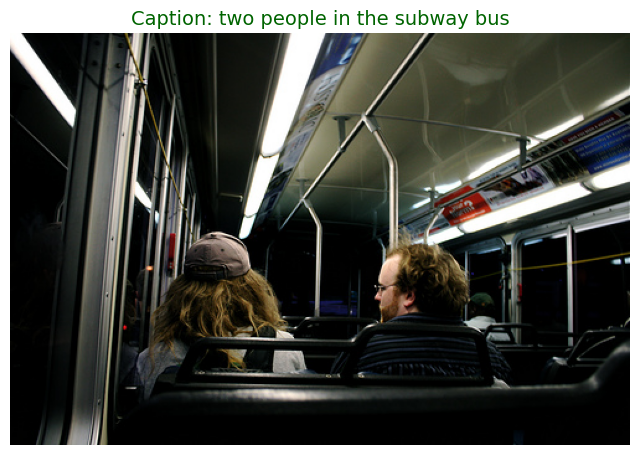

In [55]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random

#  Lấy ngẫu nhiên MỘT đường dẫn ảnh từ tập test
# lấy từ danh sách các đường dẫn ảnh duy nhất trong test_data
unique_test_image_paths = test_data['image_path'].drop_duplicates().tolist()
if not unique_test_image_paths:
    print("Không có ảnh nào trong tập test_data để hiển thị.")
else:
    # Chọn một ảnh ngẫu nhiên
    image_path = random.choice(unique_test_image_paths)

    print(f"Đang xử lý và hiển thị ảnh: {image_path}...")

    try:
        # Sinh caption từ model
        # Đảm bảo hàm generate_caption_attention đã được cập nhật
        generated_caption = generate_caption_attention(
            image_path=image_path,
            encoder=encoder,
            decoder=decoder,
            word2idx=word2idx,
            idx2word=idx2word,
            max_length=30
        )

        # Vẽ ảnh và hiển thị Caption dự đoán
        plt.figure(figsize=(8, 8)) # Kích thước hình ảnh
        img = mpimg.imread(image_path)
        plt.imshow(img)
        
        # Đặt tiêu đề là caption máy dự đoán
        plt.title(f"Caption: {generated_caption}", 
                  fontsize=14, color='darkgreen', loc='center', wrap=True) # wrap=True để caption dài tự xuống dòng
        plt.axis('off') 
        plt.show()

    except Exception as e:
        print(f"Gặp lỗi khi sinh caption cho ảnh {image_path}: {e}")

In [45]:
class ImageCaptioningModel(tf.keras.Model):
    def __init__(self, encoder, decoder):
        super(ImageCaptioningModel, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def call(self, inputs):
        # inputs gồm: [hình_ảnh_features, token_input, hidden_state]
        # Hàm này định nghĩa luồng dữ liệu để Keras biết cách lưu đồ thị tính toán
        img_tensor, seq_input, hidden = inputs
        
        #  Ảnh đi qua Encoder
        features = self.encoder(img_tensor)
        
        #  Features + Text đi qua Decoder
        output, state, attention_weights = self.decoder(seq_input, features, hidden)
        
        return output, state, attention_weights

# Khởi tạo mô hình tổng hợp với encoder và decoder đã train
full_model = ImageCaptioningModel(encoder, decoder)

In [47]:
# Tạo dữ liệu giả để kích hoạt việc xây dựng model
# Batch size = 1
dummy_img = tf.zeros((1, 8, 8, 2048)) # Giả lập features từ InceptionV3
dummy_seq = tf.zeros((1, 1))          # Giả lập 1 từ đầu vào
dummy_hidden = decoder.reset_state(batch_size=1)

# Gọi hàm call 1 lần
_ = full_model([dummy_img, dummy_seq, dummy_hidden])

print("Đã xây dựng xong mô hình tổng hợp!")

Đã xây dựng xong mô hình tổng hợp!


In [49]:
# Lưu toàn bộ
full_model.save("data/full_caption_model_2.keras")
print(" Đã lưu ")

 Đã lưu 


In [35]:
import numpy as np
import pandas as pd
from tqdm import tqdm

from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

smoothie = SmoothingFunction().method4

def strip_special_tokens(text):
    tokens = text.split()
    tokens = [t for t in tokens if t not in ["<start>", "<end>"]]
    return " ".join(tokens)

def attention_generate(img_path):
    return generate_caption_attention(
        image_path=img_path,
        encoder=encoder,
        decoder=decoder,
        word2idx=word2idx,
        idx2word=idx2word,
        max_length=max_length
    )

def prepare_test_refs_hyps_att(generate_fn):
    test_image_paths = test_data["image_path"].unique()

    used_image_paths = []
    all_refs = []
    all_hyps = []

    for img_path in tqdm(test_image_paths):
        caps = test_data.loc[test_data["image_path"] == img_path, "final_caption"].tolist()
        caps = [strip_special_tokens(c) for c in caps]

        if len(caps) == 0:
            continue

        try:
            hyp = generate_fn(img_path)
            hyp = strip_special_tokens(hyp)
        except Exception as e:
            print(f"Lỗi sinh caption cho {img_path}: {e}")
            continue

        used_image_paths.append(img_path)
        all_refs.append(caps)
        all_hyps.append(hyp)

    return used_image_paths, all_refs, all_hyps

def compute_scores(references, hypotheses):
    refs_tokens = [[r.split() for r in refs] for refs in references]
    hyps_tokens = [h.split() for h in hypotheses]

    bleu1 = corpus_bleu(refs_tokens, hyps_tokens,
                        weights=(1, 0, 0, 0),
                        smoothing_function=smoothie)
    bleu2 = corpus_bleu(refs_tokens, hyps_tokens,
                        weights=(0.5, 0.5, 0, 0),
                        smoothing_function=smoothie)
    bleu3 = corpus_bleu(refs_tokens, hyps_tokens,
                        weights=(1/3, 1/3, 1/3, 0),
                        smoothing_function=smoothie)
    bleu4 = corpus_bleu(refs_tokens, hyps_tokens,
                        weights=(0.25, 0.25, 0.25, 0.25),
                        smoothing_function=smoothie)

    # METEOR (phải token hóa)
    meteor_list = [
        meteor_score([r.split() for r in refs], hyp.split())
        for refs, hyp in zip(references, hypotheses)
    ]
    meteor_avg = float(np.mean(meteor_list))

    # ROUGE 
    scorer = rouge_scorer.RougeScorer(["rouge1", "rougeL"], use_stemmer=True)
    rouge1_list, rougeL_list = [], []

    for refs, hyp in zip(references, hypotheses):
        score = scorer.score(refs[0], hyp)
        rouge1_list.append(score["rouge1"].fmeasure)
        rougeL_list.append(score["rougeL"].fmeasure)

    return {
        "BLEU-1": bleu1,
        "BLEU-2": bleu2,
        "BLEU-3": bleu3,
        "BLEU-4": bleu4,
        "METEOR": meteor_avg,
        "ROUGE-1": float(np.mean(rouge1_list)),
        "ROUGE-L": float(np.mean(rougeL_list)),
    }


# Chuẩn bị và đánh giá
used_paths_att, refs_att, hyps_att = prepare_test_refs_hyps_att(attention_generate)
metrics_att = compute_scores(refs_att, hyps_att)

print("=== KẾT QUẢ TRÊN TẬP TEST – MÔ HÌNH ATTENTION ===")
for k, v in metrics_att.items():
    print(f"{k}: {v:.4f}")

df_eval_att = pd.DataFrame({
    "image_path": used_paths_att,
    "prediction": hyps_att,
    "references": [" | ".join(r) for r in refs_att],
})

df_eval_att.head(10)

100%|██████████████████████████████████████████████████████████████████████████████| 1619/1619 [17:36<00:00,  1.53it/s]


=== KẾT QUẢ TRÊN TẬP TEST – MÔ HÌNH ATTENTION ===
BLEU-1: 0.4816
BLEU-2: 0.2992
BLEU-3: 0.1770
BLEU-4: 0.1023
METEOR: 0.2936
ROUGE-1: 0.2334
ROUGE-L: 0.2242


,image_path,prediction,references
0,data/Images/1022454428_b6b660a67b.jpg,two people are playing with two people in fron...,couple and an infant being held by the male si...
1,data/Images/102351840_323e3de834.jpg,two people are walking on the ocean,man drilling hole in the ice | man is drilling...
2,data/Images/1028205764_7e8df9a2ea.jpg,man is riding yellow kayak,man and baby are in yellow kayak on water | ma...
3,data/Images/103195344_5d2dc613a3.jpg,two men are walking down the air,man in black is sitting next to modern art str...
4,data/Images/104136873_5b5d41be75.jpg,group of people sit on the mountains,people sit on the mountainside and check out t...
5,data/Images/1042590306_95dea0916c.jpg,two girls in black and blue and blue,man and woman pose for the camera while anothe...
6,data/Images/105342180_4d4a40b47f.jpg,girl in white swimsuit is in the water,girl paddling down large river as seen from be...
7,data/Images/1056249424_ef2a2e041c.jpg,two men are running along the edge of the back...,the children are playing in the water | two bo...
8,data/Images/106490881_5a2dd9b7bd.jpg,boy in shorts is running through the water,boy in his blue swim shorts at the beach | boy...
9,data/Images/1067180831_a59dc64344.jpg,black and white dog is running on the grass,black and white dog is attempting to catch yel...


## Kết luận

Mô hình Encoder-Decoder kết hợp Attention có khả năng
sinh mô tả ảnh mang tính ngữ nghĩa.

Chất lượng mô hình phụ thuộc vào:
- Kích thước và chất lượng dữ liệu
- Kiến trúc Encoder
- Cơ chế Attention

Hướng phát triển:
- Sử dụng CNN pretrained mạnh hơn (ResNet)
- Fine-tune Encoder
- Tăng kích thước dữ liệu huấn luyện